# A/B Testing Analysis Using Marketing Campaign Dataset

## Objective

The objective of this project is to perform an A/B test analysis using a public marketing campaign dataset to determine whether there is a statistically significant difference between two customer groups. The analysis aims to evaluate campaign effectiveness by comparing customer behavior and purchase patterns using statistical testing, confidence intervals, and practical interpretation of results.

## About the Dataset

The dataset used in this analysis is the **Marketing Campaign Dataset** obtained from Kaggle (Customer Personality Analysis dataset). It contains customer demographic information, purchasing behavior, and responses to marketing campaigns.

The dataset includes variables related to:

- Customer demographics (income, education, marital status, age)
- Spending across different product categories
- Customer engagement and purchase behavior
- Marketing campaign responses

For this A/B testing analysis, the dataset will be adapted to simulate an experiment by dividing customers into two groups based on campaign response behavior and comparing their outcomes using statistical methods.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load dataset
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Data Inspection and Understanding

Before performing the A/B test analysis, it is important to understand the structure and characteristics of the dataset. This step helps identify the number of observations, available variables, data types, and potential missing values.

Understanding the dataset is essential for selecting appropriate variables to define the control and treatment groups and for determining the primary metric used in the statistical analysis.

In [2]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns in Dataset:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (2240, 29)

Columns in Dataset:
Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income       

## Data Quality Assessment

the dataset must be checked for potential quality issues such as missing values and unusual patterns. Data quality assessment helps us ensure the statistical analysis is reliable and minimizes bias in the experiment.

This step includes checking for missing values and reviewing summary statistics to better understand customer behavior and spending patterns.

In [5]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
df.describe()

Missing Values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Summary Statistics:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## Handling Missing Values

During the data quality assessment, missing values were identified in the `Income` variable. Since income may influence customer spending behavior, these missing values could affect the reliability of the analysis.

Because the number of missing values is relatively small compared to the total dataset size, rows containing missing income values will be removed to maintain data consistency and avoid introducing bias through imputation.

In [6]:
# Check shape before cleaning
print("Shape before removing missing values:", df.shape)

# Remove rows with missing Income values
df = df.dropna(subset=["Income"])

# Check shape after cleaning
print("Shape after removing missing values:", df.shape)

# Verify missing values again
print("\nMissing Values:")
print(df.isnull().sum())

Shape before removing missing values: (2240, 29)
Shape after removing missing values: (2216, 29)

Missing Values:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


## A/B Test Design

To adapt the marketing dataset for A/B testing, lets divide customers into two groups based on campaign response behavior.

### Group Definition

- **Group A (Control Group):** Customers who did not respond to the marketing campaign (`Response = 0`)
- **Group B (Treatment Group):** Customers who responded to the marketing campaign (`Response = 1`)

### Primary Metric

The primary metric selected for comparison is **Total Spending**.

Lets create new variable called `Total_Spending` by summing customer spending across product categories:

- Wines
- Fruits
- Meat Products
- Fish Products
- Sweet Products
- Gold Products

This metric helps evaluate whether customers in the treatment group demonstrate different purchasing behavior compared to the control group.

### Hypotheses

Let:

- **A** = average total spending of the control group
- **B** = average total spending of the treatment group

**Null Hypothesis (H₀):**  
There is no significant difference in average total spending between the two groups.

**A** = **B**

**Alternative Hypothesis (H₁):**  
There is a significant difference in average total spending between the two groups.

**A** ≠ **B**

In [8]:
# Create Total Spending column
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

# Define A and B groups
group_A = df[df["Response"] == 0]
group_B = df[df["Response"] == 1]

# Check group sizes
print("Control Group (A) Size:", len(group_A))
print("Treatment Group (B) Size:", len(group_B))

# Display average spending
print("\nAverage Spending:")
print("Group A:", group_A["Total_Spending"].mean())
print("Group B:", group_B["Total_Spending"].mean())


Control Group (A) Size: 1883
Treatment Group (B) Size: 333

Average Spending:
Group A: 540.1242697822623
Group B: 985.6606606606607


## Exploratory Data Analysis (EDA)

Before applying statistical testing, Lets perforn EDA to understand the distribution of spending across both groups and identify any unusual patterns or potential biases.

This step helps determine whether meaningful differences exist between the control and treatment groups and provides visual insight into customer spending behavior.

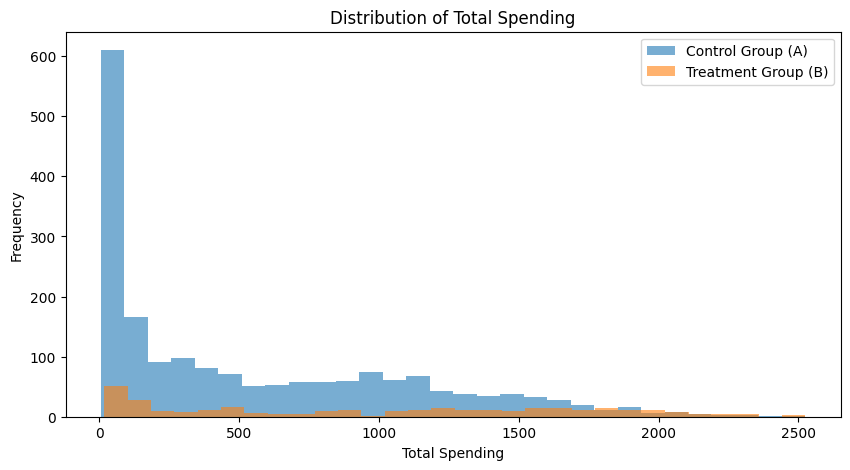

In [9]:
# Distribution of Total Spending for A and B groups

plt.figure(figsize=(10,5))

plt.hist(group_A["Total_Spending"],
         bins=30,
         alpha=0.6,
         label="Control Group (A)")

plt.hist(group_B["Total_Spending"],
         bins=30,
         alpha=0.6,
         label="Treatment Group (B)")

plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.title("Distribution of Total Spending")
plt.legend()

plt.show()

### Interpretation of Spending Distribution

On comparing the distribution of total spending between the control group (A) and treatment group (B).

Several observations can be made from the visualization:

- The treatment group generally appears to have higher spending values compared to the control group.
- Both groups show a right-skewed distribution, meaning most customers spend lower amounts while a smaller number of customers spend significantly higher amounts.
- Some high-spending outliers are visible in both groups, which is common in customer purchase data.
- The treatment group distribution appears shifted toward higher spending levels, suggesting that customers who responded to the campaign may spend more on average.

Although visual differences are noticeable, statistical testing is required to determine whether these differences are statistically significant or due to random variation.

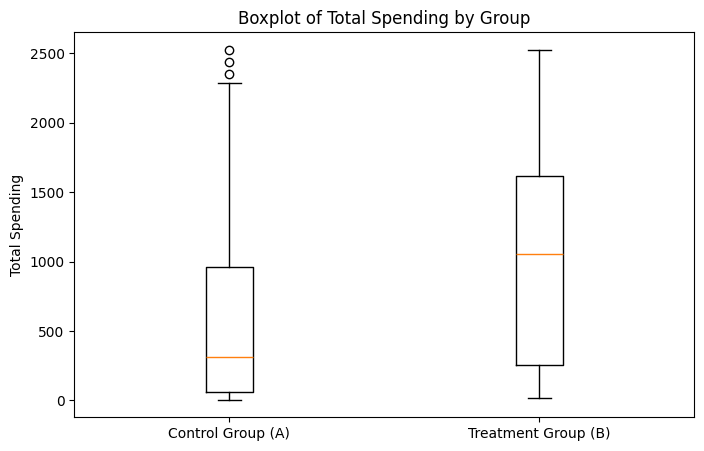

In [11]:
# Boxplot comparison

plt.figure(figsize=(8,5))

plt.boxplot(
    [group_A["Total_Spending"], group_B["Total_Spending"]],
    tick_labels=["Control Group (A)", "Treatment Group (B)"]
)

plt.ylabel("Total Spending")
plt.title("Boxplot of Total Spending by Group")

plt.show()

### Interpretation of the Boxplot

The boxplot compares the distribution of total spending between the control group (A) and treatment group (B).

From the visualization, the treatment group appears to have a higher median spending level than the control group, suggesting that customers who responded to the campaign tend to spend more overall. The treatment group also shows a wider spread in spending values, indicating greater variability in customer purchasing behavior.


## Statistical Testing

To determine whether the difference in total spending between the control and treatment groups is statistically significant, we perform **independent two-sample t-test** .

The t-test is appropriate because the analysis compares the average spending between two independent groups.

The decision rule is:

- If **p-value < 0.05**, reject the null hypothesis and conclude there is a statistically significant difference.
- If **p-value ≥ 0.05**, fail to reject the null hypothesis and conclude there is no statistically significant difference.

In [12]:
# Independent t-test

t_stat, p_value = stats.ttest_ind(
    group_A["Total_Spending"],
    group_B["Total_Spending"],
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", p_value)


T-Statistic: -10.7522
P-Value: 6.924816846367222e-24


### T-Test Interpretation

After the independent t-test to compare the avg total spending between the control group and treatment group, the result are 

- **T-statistic = -10.7522**
- **P-value = 6.92e-24**

Since the p-value is significantly smaller than the significance level of **0.05**, the null hypothesis is rejected.

This indicates that there is a statistically significant difference in average total spending between the two groups.

In comparison to the control group, the treatment group shows higher spending pattern, indicating that the marketing campaign reaction is associated with increased consumer spending.

In [14]:
# Mean difference
mean_diff = (
    group_B["Total_Spending"].mean()
    - group_A["Total_Spending"].mean()
)

# Standard error
se = np.sqrt(
    (group_A["Total_Spending"].var() / len(group_A))
    +
    (group_B["Total_Spending"].var() / len(group_B))
)

# 95% confidence interval
margin_error = stats.norm.ppf(0.975) * se

lower_ci = mean_diff - margin_error
upper_ci = mean_diff + margin_error

print("Mean Difference:", round(mean_diff, 2))
print("95% Confidence Interval:")
print(f"({round(lower_ci,2)}, {round(upper_ci,2)})")

Mean Difference: 445.54
95% Confidence Interval:
(364.32, 526.75)


### Confidence Interval Interpretation

The mean difference in total spending between the treatment group and control group is **445.54**.

The 95% confidence interval ranges from **364.32 to 526.75**, meaning that the true difference in average spending is likely to fall within this range.

Since the confidence interval does not include **0**, this further supports the conclusion that there is a statistically significant difference between the two groups.

Additionally, the positive interval values indicate that the treatment group consistently spends more than the control group, suggesting a meaningful practical impact of the marketing campaign response.

## Final Conclusion and Recommendation

From the A/B testing analysis, we can see that there is a clear difference between Group A and Group B in terms of total spending.

The t-test result gave a very small p-value (**6.92e-24**), which is much smaller than **0.05**. Because of this, we reject the null hypothesis and conclude that there is a statistically significant difference between the two groups.

Also, the **95% confidence interval (364.32, 526.75)** does not contain 0, which supports the result that the treatment group spends more than the control group.

The treatment group (Group B) has an average spending that is around **445.54 higher** than the control group (Group A).

### Recommendation

Based on the analysis, the **B variant can be recommended** because customers in this group show higher spending compared to Group A.

However, since this dataset was adapted to simulate an A/B test, other factors like customer income, demographics, and buying behavior may also influence the results. So, in a real-world scenario, it would be better to test this with a randomized experiment before making a final business decision.